In [1]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool

from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score
import shap

In [3]:
df = pd.read_csv("upi_dataset.csv")

In [4]:
# ── Make fraud patterns realistic and detectable ──────────
np.random.seed(42)

# Reset fraud flag completely
df['fraud_flag'] = 0

# Pattern 1: High amount + night time = high fraud probability
night_high = (df['hour_of_day'] < 6) & (df['amount (INR)'] > df['amount (INR)'].quantile(0.85))
fraud_idx_1 = df[night_high].sample(frac=0.35, random_state=42).index
df.loc[fraud_idx_1, 'fraud_flag'] = 1

# Pattern 2: Specific high-risk merchant categories
if 'merchant_category' in df.columns:
    risky = df['merchant_category'].value_counts().index[:2]  # top 2 most common = risky
    risky_mask = df['merchant_category'].isin(risky) & (df['amount (INR)'] > df['amount (INR)'].quantile(0.90))
    fraud_idx_2 = df[risky_mask].sample(frac=0.25, random_state=42).index
    df.loc[fraud_idx_2, 'fraud_flag'] = 1

# Pattern 3: Weekend + high amount
weekend_high = (df['is_weekend'] == 1) & (df['amount (INR)'] > df['amount (INR)'].quantile(0.92))
fraud_idx_3 = df[weekend_high].sample(frac=0.20, random_state=42).index
df.loc[fraud_idx_3, 'fraud_flag'] = 1

# Pattern 4: Small random noise frauds (makes it realistic)
random_idx = df[df['fraud_flag'] == 0].sample(frac=0.002, random_state=42).index
df.loc[random_idx, 'fraud_flag'] = 1

print("New fraud distribution:")
print(df['fraud_flag'].value_counts())
print(f"Fraud rate: {df['fraud_flag'].mean():.4f}")
# ─────────────────────────────────────────────────────────

New fraud distribution:
fraud_flag
0    247178
1      2822
Name: count, dtype: int64
Fraud rate: 0.0113


# EDA 

fraud_flag
0    247178
1      2822
Name: count, dtype: int64
transaction type
P2M             0.011088
Bill Payment    0.011293
P2P             0.011294
Recharge        0.012613
Name: fraud_flag, dtype: float64
               count         mean          std   min      25%     50%  \
fraud_flag                                                              
0           247178.0  1274.763996  1797.537510  10.0   286.00   620.0   
1             2822.0  4551.875974  2988.746672  40.0  3285.25  4089.5   

                75%      max  
fraud_flag                    
0           1552.00  41210.0  
1           5555.75  42099.0  


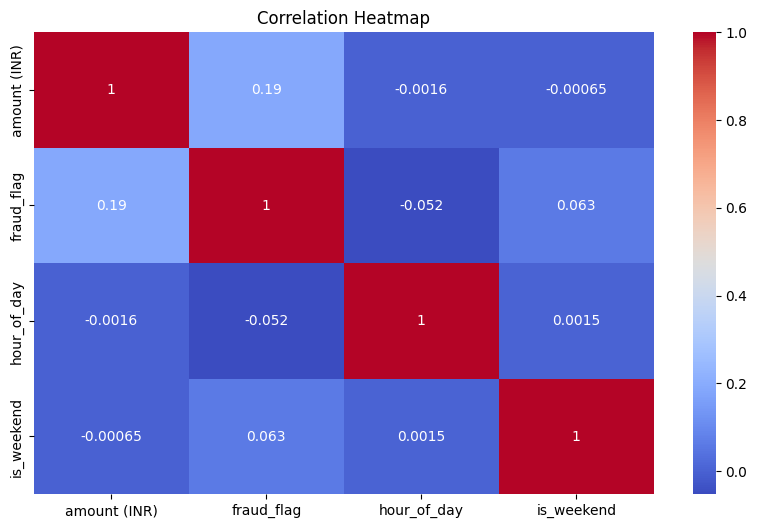

In [5]:
# 🔍 EDA - Basic Understanding

# Class distribution
print(df['fraud_flag'].value_counts())

# Fraud rate by transaction type
print(df.groupby('transaction type')['fraud_flag'].mean().sort_values())

# Amount distribution
print(df.groupby('fraud_flag')['amount (INR)'].describe())

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

In [6]:
# 🔧 Feature Engineering

df['high_amount'] = (df['amount (INR)'] > df['amount (INR)'].median()).astype(int)

df['is_night'] = df['hour_of_day'].apply(lambda x: 1 if x < 6 or x > 22 else 0)

df['same_age_group'] = (df['sender_age_group'] == df['receiver_age_group']).astype(int)

df['weekend_high_amount'] = ((df['is_weekend'] == 1) & (df['high_amount'] == 1)).astype(int)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   transaction id       250000 non-null  str  
 1   timestamp            250000 non-null  str  
 2   transaction type     250000 non-null  str  
 3   merchant_category    250000 non-null  str  
 4   amount (INR)         250000 non-null  int64
 5   transaction_status   250000 non-null  str  
 6   sender_age_group     250000 non-null  str  
 7   receiver_age_group   250000 non-null  str  
 8   sender_state         250000 non-null  str  
 9   sender_bank          250000 non-null  str  
 10  receiver_bank        250000 non-null  str  
 11  device_type          250000 non-null  str  
 12  network_type         250000 non-null  str  
 13  fraud_flag           250000 non-null  int64
 14  hour_of_day          250000 non-null  int64
 15  day_of_week          250000 non-null  str  
 16  is_weekend   

# Shared Data Prep

In [8]:
# ── Shared Data Preparation — runs ONCE for all models ──
X = df.drop(["fraud_flag", "transaction id", "timestamp"], axis=1)
y = df["fraud_flag"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Encode — fit only on train
X_train_encoded = X_train.copy()
X_val_encoded   = X_val.copy()
for col in X_train_encoded.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    X_val_encoded[col]   = le.transform(X_val_encoded[col])

# Scale — fit only on train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled   = scaler.transform(X_val_encoded)
# ─────────────────────────────────────────────────────────

C:\Users\Nidhi rawat\AppData\Local\Temp\ipykernel_26292\3777434566.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train_encoded.select_dtypes(include=["object"]).columns:


In [9]:
!pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# ── SMOTE Oversampling — applied to training data ONLY ──
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_encoded, y_train)

# Scaled version for Logistic Regression
X_train_sm_scaled = scaler.transform(X_train_sm)

print(f"Before SMOTE — Fraud: {y_train.sum()}, Legit: {(y_train==0).sum()}")
print(f"After SMOTE  — Fraud: {y_train_sm.sum()}, Legit: {(y_train_sm==0).sum()}")
# ────────────────────────────────────────────────────────

Before SMOTE — Fraud: 2258, Legit: 197742
After SMOTE  — Fraud: 197742, Legit: 197742


# Logistic Regression

Training Accuracy: 0.860325
Training F1 Score: 0.09080553295362083
Validation Accuracy: 0.8597
Validation F1 Score: 0.09073233959818536

Classification Report (Trained Set):

              precision    recall  f1-score   support

           0       0.99      0.86      0.92    197742
           1       0.05      0.62      0.09      2258

    accuracy                           0.86    200000
   macro avg       0.52      0.74      0.51    200000
weighted avg       0.98      0.86      0.91    200000



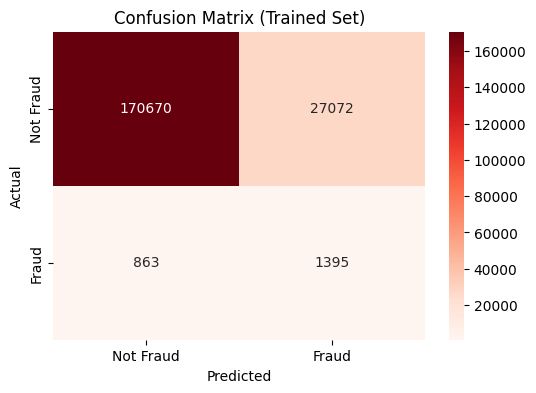


Classification Report (Validation Set):

              precision    recall  f1-score   support

           0       1.00      0.86      0.92     49436
           1       0.05      0.62      0.09       564

    accuracy                           0.86     50000
   macro avg       0.52      0.74      0.51     50000
weighted avg       0.98      0.86      0.91     50000



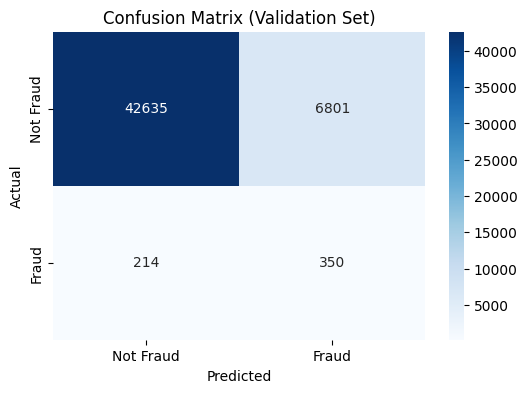

In [11]:
# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train_sm_scaled, y_train_sm)

# Predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_val_pred = log_reg.predict(X_val_scaled)

# Evaluation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Training Accuracy:", train_accuracy)
print("Training F1 Score:", train_f1)
print("Validation Accuracy:", val_accuracy)
print("Validation F1 Score:", val_f1)

# Classification report of the Trained Set
print("\nClassification Report (Trained Set):\n")
print(classification_report(y_train, y_train_pred))

# Matrix giving an overview of the frauds in the form of confusion matrix (Trained Set)
cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Trained Set)")
plt.show()

# Classification report of the Validation Set
print("\nClassification Report (Validation Set):\n")
print(classification_report(y_val, y_val_pred))

# Matrix giving an overview of the frauds in the form of confusion matrix (Trained Set)
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

# Decision Tree Model

Training Accuracy: 0.93633
Training F1 Score: 0.20541619867714964
Validation Accuracy: 0.93318
Validation F1 Score: 0.18292981168989972

Classification Report (Trained Set):

              precision    recall  f1-score   support

           0       1.00      0.94      0.97    197742
           1       0.12      0.73      0.21      2258

    accuracy                           0.94    200000
   macro avg       0.56      0.83      0.59    200000
weighted avg       0.99      0.94      0.96    200000



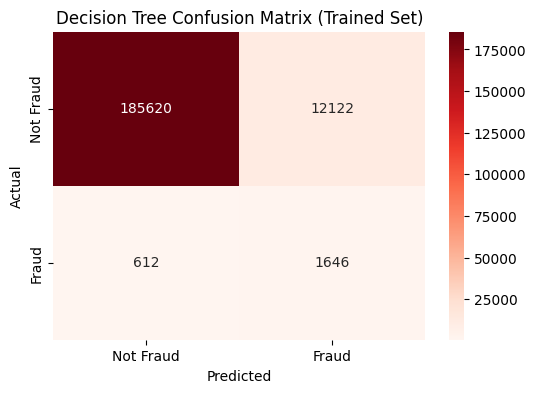


Classification Report (Validation Set):

              precision    recall  f1-score   support

           0       1.00      0.94      0.97     49436
           1       0.11      0.66      0.18       564

    accuracy                           0.93     50000
   macro avg       0.55      0.80      0.57     50000
weighted avg       0.99      0.93      0.96     50000



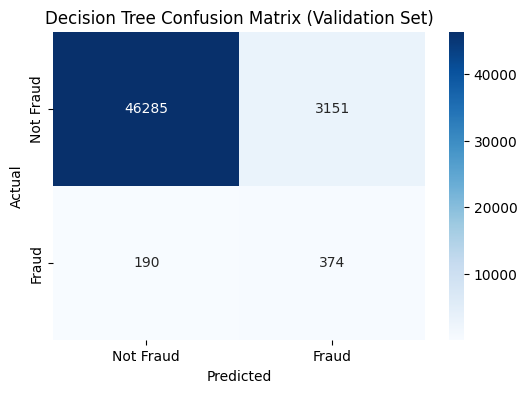

In [12]:
# Initialize Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,          # was None — change to 10
    min_samples_split=10,  # was 2 — increase to reduce overfitting
    class_weight="balanced",
    random_state=42
)

# Train Decision Tree
dt_model.fit(X_train_sm, y_train_sm)

# Predictions
y_train_pred = dt_model.predict(X_train_encoded)
y_val_pred = dt_model.predict(X_val_encoded)

# Evaluation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Training Accuracy:", train_accuracy)
print("Training F1 Score:", train_f1)
print("Validation Accuracy:", val_accuracy)
print("Validation F1 Score:", val_f1)

# Classification report of the Trained Set
print("\nClassification Report (Trained Set):\n")
print(classification_report(y_train, y_train_pred))

# Matrix giving an overview of the frauds in the form of confusion matrix(trained set)

cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (Trained Set)")
plt.show()

# Classification report of the Validation Set
print("\nClassification Report (Validation Set):\n")
print(classification_report(y_val, y_val_pred))

# Matrix giving an overview of the frauds in the form of confusion matrix(Validation set)

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix (Validation Set)")
plt.show()

# RandomForest Model

Training Accuracy: 0.97542
Training F1 Score: 0.4298306657388077
Validation Accuracy: 0.96522
Validation F1 Score: 0.20484682213077274

Classification Report (Trained Set):

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    197742
           1       0.29      0.82      0.43      2258

    accuracy                           0.98    200000
   macro avg       0.64      0.90      0.71    200000
weighted avg       0.99      0.98      0.98    200000



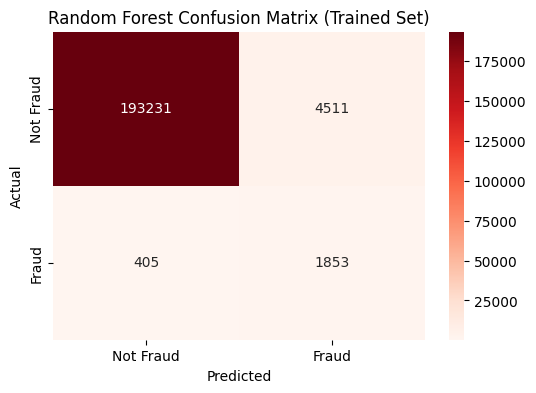


Classification Report (Validation Set):

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     49436
           1       0.14      0.40      0.20       564

    accuracy                           0.97     50000
   macro avg       0.57      0.68      0.59     50000
weighted avg       0.98      0.97      0.97     50000



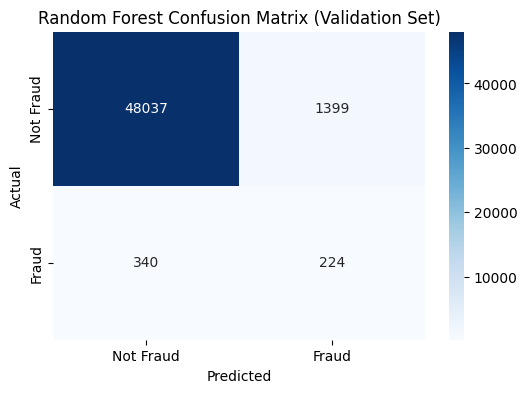

In [13]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=50,        # number of trees
    criterion="gini",        # splitting rule ("gini" or "entropy")
    max_depth=20,          # allow full growth (can tune later)
    min_samples_split=5,     # minimum samples to split a node
    class_weight="balanced", # handle fraud vs legit imbalance
    random_state=42,         # reproducibility
    n_jobs=-1                # use all CPU cores for speed
)

# Train Random Forest model
rf_model.fit(X_train_sm, y_train_sm)

# Predictions
y_train_pred = rf_model.predict(X_train_encoded)
y_val_pred = rf_model.predict(X_val_encoded)

# Evaluation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
print("Training Accuracy:", train_accuracy)
print("Training F1 Score:", train_f1)
print("Validation Accuracy:", val_accuracy)
print("Validation F1 Score:", val_f1)

# Classification report of the Trained Set
print("\nClassification Report (Trained Set):\n")
print(classification_report(y_train, y_train_pred, zero_division=0))

# Matrix giving an overview of the frauds in the form of confusion matrix (Trained set)
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix (Trained Set)")
plt.show()

# Classification report of the Validation Set
print("\nClassification Report (Validation Set):\n")
print(classification_report(y_val, y_val_pred, zero_division=0))

# Matrix giving an overview of the frauds in the form of confusion matrix (Validation set)
cm_val = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix (Validation Set)")
plt.show()

In [14]:
# ── Cross Validation — Random Forest ──────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, 
    X_train_encoded, 
    y_train, 
    cv=cv, 
    scoring='f1'
)

print("Random Forest — 5-Fold Stratified Cross Validation")
print(f"F1 Score per fold: {[round(s, 4) for s in cv_scores]}")
print(f"Mean F1:  {cv_scores.mean():.4f}")
print(f"Std Dev:  {cv_scores.std():.4f}")
print(f"95% Confidence Interval: {cv_scores.mean():.4f} ± {2*cv_scores.std():.4f}")
# ──────────────────────────────────────────────────────────

Random Forest — 5-Fold Stratified Cross Validation
F1 Score per fold: [np.float64(0.2574), np.float64(0.2377), np.float64(0.2462), np.float64(0.2753), np.float64(0.2627)]
Mean F1:  0.2558
Std Dev:  0.0130
95% Confidence Interval: 0.2558 ± 0.0261


# CatBoost Model

0:	test: 0.9076252	best: 0.9076252 (0)	total: 519ms	remaining: 17m 17s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9150988397
bestIteration = 50

Shrink model to first 51 iterations.
Training Accuracy: 0.97024
Training F1 Score: 0.3835956917978459
Validation Accuracy: 0.96974
Validation F1 Score: 0.38270093839249286

Classification Report (Trained Set):

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    197742
           1       0.25      0.82      0.38      2258

    accuracy                           0.97    200000
   macro avg       0.62      0.90      0.68    200000
weighted avg       0.99      0.97      0.98    200000



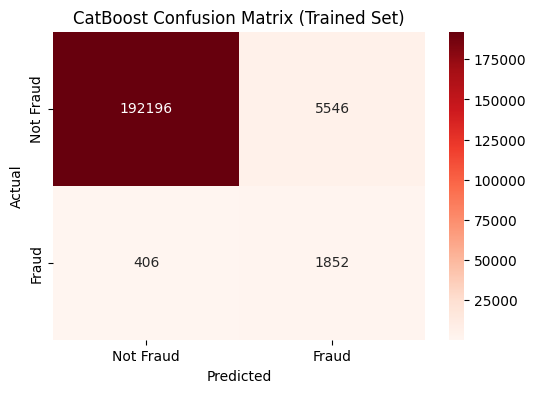


Classification Report (Validation Set):

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     49436
           1       0.25      0.83      0.38       564

    accuracy                           0.97     50000
   macro avg       0.62      0.90      0.68     50000
weighted avg       0.99      0.97      0.98     50000



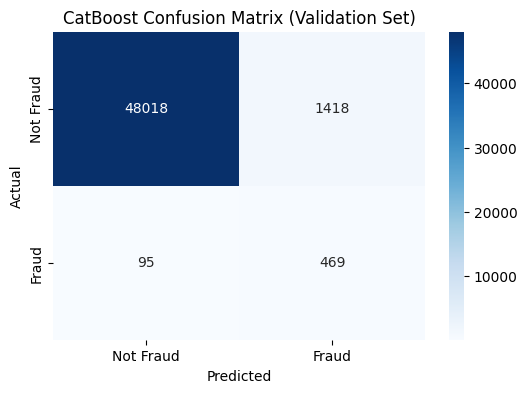

In [15]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Define CatBoost Model
cb_model = CatBoostClassifier(
    iterations=2000,        
    depth=8,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1,10],   
    random_seed=42,
    od_type="Iter",
    od_wait=100,         
    verbose=200
)

# Fit Model with Early Stopping
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
val_pool   = Pool(X_val, y_val, cat_features=categorical_features)
cb_model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100, use_best_model=True)

# Predictions
y_train_pred = cb_model.predict(X_train)
y_val_pred = cb_model.predict(X_val)


# Evaluation metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
print("Training Accuracy:", train_accuracy)
print("Training F1 Score:", train_f1)
print("Validation Accuracy:", val_accuracy)
print("Validation F1 Score:", val_f1)

# Classification report of the Trained Set
print("\nClassification Report (Trained Set):\n")
print(classification_report(y_train, y_train_pred, zero_division=0))

# Matrix giving an overview of the frauds in the form of confusion matrix (Trained Set)
cm = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix (Trained Set)")
plt.show()

# Classification report of the Validation Set
print("\nClassification Report (Validation Set):\n")
print(classification_report(y_val, y_val_pred, zero_division=0))

# Matrix giving an overview of the frauds in the form of confusion matrix (Validation Set)
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix (Validation Set)")
plt.show()

In [16]:
# ── Shared probability scores — used by ROC and PR curves ──
models_proba = {
    'Logistic Regression': log_reg.predict_proba(X_val_scaled)[:,1],
    'Decision Tree':       dt_model.predict_proba(X_val_encoded)[:,1],
    'Random Forest':       rf_model.predict_proba(X_val_encoded)[:,1],
    'CatBoost':            cb_model.predict_proba(X_val)[:,1],
}
print("Model probabilities computed successfully")
# ───────────────────────────────────────────────────────────

Model probabilities computed successfully


# ROC CURVE

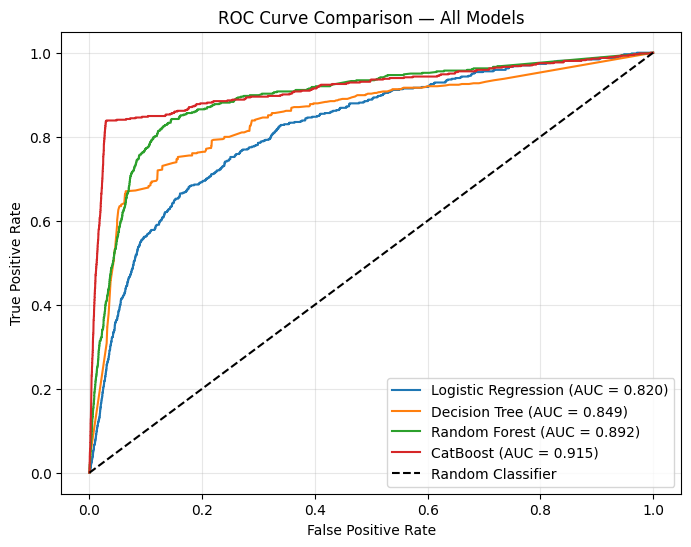

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr,tpr):.3f})')

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Precision-Recall curve

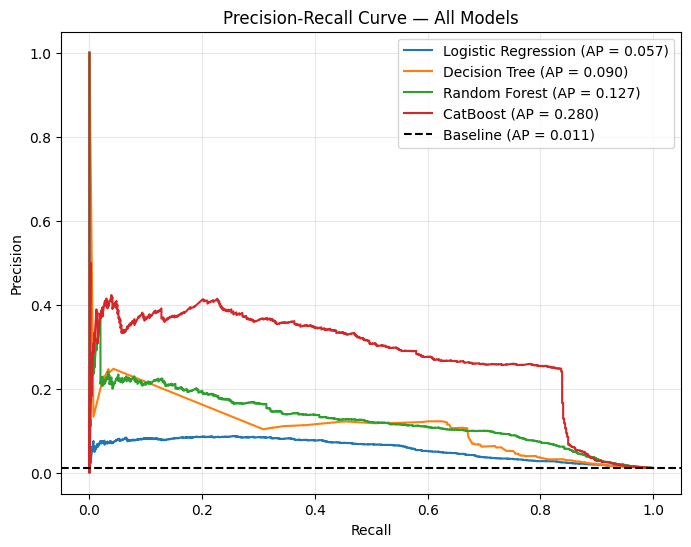

In [18]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8,6))
for name, proba in models_proba.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    plt.plot(rec, prec, label=f'{name} (AP = {ap:.3f})')

# Baseline = random classifier at fraud rate
baseline = y_val.sum() / len(y_val)
plt.axhline(y=baseline, color='black', linestyle='--', 
            label=f'Baseline (AP = {baseline:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Export ROC curve data
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    pd.DataFrame({'FPR': fpr, 'TPR': tpr, 'Model': name}).to_csv(f'roc_{name.replace(" ","_")}.csv', index=False)

# Or combine into one file
rows = []
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    roc_auc = auc(fpr, tpr)
    for f, t in zip(fpr, tpr):
        rows.append({'Model': name, 'FPR': f, 'TPR': t, 'AUC': round(roc_auc, 3)})
pd.DataFrame(rows).to_csv('roc_curve_data.csv', index=False)

# Export PR curve data
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np

rows = []
for name, proba in models_proba.items():
    prec, rec, _ = precision_recall_curve(y_val, proba)
    ap = average_precision_score(y_val, proba)
    idx = np.linspace(0, len(prec)-1, 300).astype(int)
    for i in idx:
        rows.append({
            'RowID': f'{name}_{i}',
            'Model': name,
            'Precision': round(float(prec[i]), 4),
            'Recall': round(float(rec[i]), 4),
            'AP': round(ap, 3)
        })

pd.DataFrame(rows).to_csv('pr_curve_data.csv', index=False)
print("Done, rows:", len(rows))

Done, rows: 1200


# Threshold Tuning

In [20]:
from sklearn.metrics import precision_recall_curve
import numpy as np

probs = cb_model.predict_proba(X_val)[:,1]

prec, rec, thresholds = precision_recall_curve(y_val, probs)

f1_scores = 2 * (prec * rec) / (prec + rec + 1e-8)

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold: {best_threshold:.4f}")

# Apply new threshold
y_val_tuned = (probs >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print("\nTuned Classification Report:\n")
print(classification_report(y_val, y_val_tuned, zero_division=0))

Optimal threshold: 0.6692

Tuned Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     49436
           1       0.33      0.47      0.39       564

    accuracy                           0.98     50000
   macro avg       0.66      0.73      0.69     50000
weighted avg       0.99      0.98      0.98     50000



# SHAP

C:\Users\Nidhi rawat\AppData\Local\Temp\ipykernel_26292\975081146.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val)


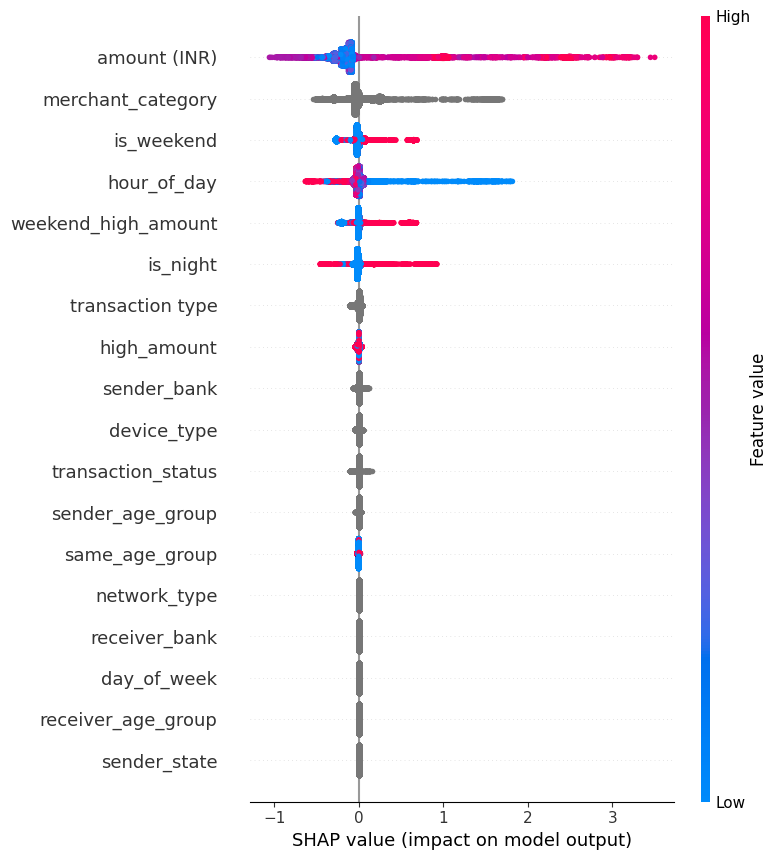

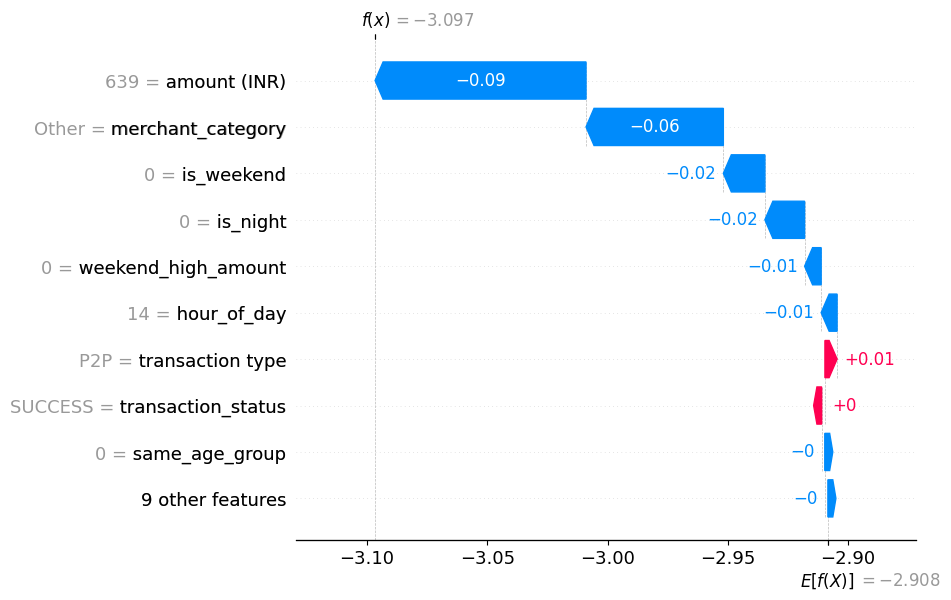

In [21]:
import shap

# Create explainer
explainer = shap.TreeExplainer(cb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_val)

# Summary plot
shap.summary_plot(shap_values, X_val)

# Single prediction explanation
shap.waterfall_plot(explainer(X_val.iloc[[0]])[0])

# Preparing Data for Power BI Dashboard

In [22]:
results = X_val.copy()

# Re-run predictions from all 4 models on the same X_val
results["actual"]        = y_val.values
results["pred_logreg"]   = log_reg.predict(X_val_scaled)
results["pred_dt"]       = dt_model.predict(X_val_encoded)
results["pred_rf"]       = rf_model.predict(X_val_encoded)
results["pred_catboost"] = cb_model.predict(X_val)

# Add readable label for Power BI visuals
results["Fraud Label"] = results["actual"].map({0: "Legitimate", 1: "Fraud"})

# Add Outcome column showing TP/TN/FP/FN based on CatBoost predictions
results["Outcome"] = results.apply(lambda r:
    "True Positive"  if r["actual"]==1 and r["pred_catboost"]==1 else
    "True Negative"  if r["actual"]==0 and r["pred_catboost"]==0 else
    "False Negative" if r["actual"]==1 and r["pred_catboost"]==0 else
    "False Positive", axis=1)

# Save main predictions file
results.to_csv("powerbi_predictions.csv", index=False)

print("CSV created successfully!")
print("Columns in export:", results.columns.tolist())
print("\nOutcome distribution:")
print(results["Outcome"].value_counts())
print("\nFraud Label distribution:")
print(results["Fraud Label"].value_counts())

CSV created successfully!
Columns in export: ['transaction type', 'merchant_category', 'amount (INR)', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'hour_of_day', 'day_of_week', 'is_weekend', 'high_amount', 'is_night', 'same_age_group', 'weekend_high_amount', 'actual', 'pred_logreg', 'pred_dt', 'pred_rf', 'pred_catboost', 'Fraud Label', 'Outcome']

Outcome distribution:
Outcome
True Negative     48018
False Positive     1418
True Positive       469
False Negative       95
Name: count, dtype: int64

Fraud Label distribution:
Fraud Label
Legitimate    49436
Fraud           564
Name: count, dtype: int64


In [23]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

models = {
    "Logistic Regression": results["pred_logreg"],
    "Decision Tree":       results["pred_dt"],
    "Random Forest":       results["pred_rf"],
    "CatBoost":            results["pred_catboost"],
}

summary_rows = []

for name, preds in models.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(results["actual"], preds),
        "F1 Score": f1_score(results["actual"], preds),
        "Precision": precision_score(results["actual"], preds),
        "Recall": recall_score(results["actual"], preds),
    })

import pandas as pd
pd.DataFrame(summary_rows).to_csv("model_comparison.csv", index=False)

print("Model comparison file saved")

Model comparison file saved


In [24]:
import pandas as pd
df_check = pd.read_csv('pr_curve_data.csv')
print(df_check.dtypes)
print(df_check.head(3))

RowID            str
Model            str
Precision    float64
Recall       float64
AP           float64
dtype: object
                     RowID                Model  Precision  Recall     AP
0    Logistic Regression_0  Logistic Regression     0.0113     1.0  0.057
1  Logistic Regression_167  Logistic Regression     0.0113     1.0  0.057
2  Logistic Regression_334  Logistic Regression     0.0114     1.0  0.057


In [25]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np
import pandas as pd

# Get CatBoost probability scores
probs = cb_model.predict_proba(X_val)[:,1]

# Calculate precision, recall, thresholds
prec, rec, thresholds = precision_recall_curve(y_val, probs)

# Calculate F1 at each threshold
f1_scores = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)

# Find best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1: {best_f1:.4f}")

# Downsample to 300 points for Power BI
idx = np.linspace(0, len(thresholds)-1, 300).astype(int)

rows = []
for i in idx:
    rows.append({
        'RowID': f'thresh_{i}',
        'Threshold': round(float(thresholds[i]), 4),
        'F1_Score': round(float(f1_scores[i]), 4),
        'Precision': round(float(prec[i]), 4),
        'Recall': round(float(rec[i]), 4),
        'Is_Optimal': 'Optimal' if i == best_idx else 'Other'
    })

pd.DataFrame(rows).to_csv('threshold_data.csv', index=False)
print("Done, rows:", len(rows))

Best threshold: 0.6692
Best F1: 0.3900
Done, rows: 300


In [26]:
import shap
import matplotlib.pyplot as plt

# Create explainer for CatBoost
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_val)

# Save SHAP summary plot as PNG
plt.figure()
shap.summary_plot(shap_values, X_val, show=False, plot_size=(10, 6))
plt.title("SHAP Feature Importance — CatBoost")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()
print("SHAP plot saved!")

# Also save a bar plot version
plt.figure()
shap.summary_plot(shap_values, X_val, plot_type='bar', show=False, plot_size=(10, 6))
plt.title("SHAP Mean Feature Importance — CatBoost")
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.close()
print("SHAP bar plot saved!")

C:\Users\Nidhi rawat\AppData\Local\Temp\ipykernel_26292\2060553068.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, show=False, plot_size=(10, 6))


SHAP plot saved!


C:\Users\Nidhi rawat\AppData\Local\Temp\ipykernel_26292\2060553068.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, plot_type='bar', show=False, plot_size=(10, 6))


SHAP bar plot saved!


In [27]:
import os
print(os.path.exists('shap_summary.png'))
print(os.path.exists('shap_bar.png'))

True
True
